## **IMPORT LIBRARIES**

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# TEXT CORPUS LOADING

In [2]:
corpus = """
to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
or to take arms against a sea of troubles
and by opposing end them

all the worlds a stage
and all the men and women merely players
they have their exits and their entrances
and one man in his time plays many parts

the course of true love never did run smooth
love looks not with the eyes but with the mind
and therefore is winged cupid painted blind

if music be the food of love play on
give me excess of it that surfeiting
the appetite may sicken and so die
"""

# TOKENIZATION

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)
print(tokenizer.word_index)

Vocabulary Size: 81
{'the': 1, 'and': 2, 'of': 3, 'to': 4, 'be': 5, 'love': 6, 'or': 7, 'not': 8, 'that': 9, 'is': 10, 'in': 11, 'mind': 12, 'a': 13, 'all': 14, 'their': 15, 'with': 16, 'question': 17, 'whether': 18, 'tis': 19, 'nobler': 20, 'suffer': 21, 'slings': 22, 'arrows': 23, 'outrageous': 24, 'fortune': 25, 'take': 26, 'arms': 27, 'against': 28, 'sea': 29, 'troubles': 30, 'by': 31, 'opposing': 32, 'end': 33, 'them': 34, 'worlds': 35, 'stage': 36, 'men': 37, 'women': 38, 'merely': 39, 'players': 40, 'they': 41, 'have': 42, 'exits': 43, 'entrances': 44, 'one': 45, 'man': 46, 'his': 47, 'time': 48, 'plays': 49, 'many': 50, 'parts': 51, 'course': 52, 'true': 53, 'never': 54, 'did': 55, 'run': 56, 'smooth': 57, 'looks': 58, 'eyes': 59, 'but': 60, 'therefore': 61, 'winged': 62, 'cupid': 63, 'painted': 64, 'blind': 65, 'if': 66, 'music': 67, 'food': 68, 'play': 69, 'on': 70, 'give': 71, 'me': 72, 'excess': 73, 'it': 74, 'surfeiting': 75, 'appetite': 76, 'may': 77, 'sicken': 78, 'so': 

## Create Training Sequences

In [4]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print("Total Sequences:", len(input_sequences))

Total Sequences: 102


# Padding

In [5]:
max_len = max([len(seq) for seq in input_sequences])

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

print("Max Length:", max_len)

Max Length: 10


# Creating X and y

In [6]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (102, 9)
y Shape: (102,)


# **Vanilla RNN Model**

In [7]:
rnn_model = Sequential([

    Embedding(
        input_dim=total_words,
        output_dim=32,
        input_length=max_len-1
    ),

    SimpleRNN(64),

    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
rnn_history = rnn_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0196 - loss: 4.4016
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0686 - loss: 4.3629
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0686 - loss: 4.3320
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0686 - loss: 4.3039
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0686 - loss: 4.2706
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0588 - loss: 4.2375
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0588 - loss: 4.2004
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0588 - loss: 4.1655
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0490 - loss: 4.1275
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0588 - loss: 4.0927
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0588 - loss: 4.0592
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0784 - lo

# **LSTM Model**

In [9]:
lstm_model = Sequential([

    Embedding(
        input_dim=total_words,
        output_dim=32,
        input_length=max_len-1
    ),

    LSTM(64),

    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
lstm_history = lstm_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.0392 - loss: 4.3940
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0784 - loss: 4.3874
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0882 - loss: 4.3811
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0784 - loss: 4.3742
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0784 - loss: 4.3648
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0686 - loss: 4.3530
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0686 - loss: 4.3327
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0686 - loss: 4.3012
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0686 - loss: 4.2602
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0686 - loss: 4.2203 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0686 - loss: 4.1923
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0686 - l

# **GRU Model**

In [11]:
gru_model = Sequential([

    Embedding(
        input_dim=total_words,
        output_dim=32,
        input_length=max_len-1
    ),

    GRU(64),

    Dense(total_words, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
gru_history = gru_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.0196 - loss: 4.3948  
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0588 - loss: 4.3861
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0686 - loss: 4.3791
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0686 - loss: 4.3728
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0980 - loss: 4.3652
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0882 - loss: 4.3571
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0882 - loss: 4.3477
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0882 - loss: 4.3358
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0882 - loss: 4.3207
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0784 - loss: 4.3009
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0882 - loss: 4.2752
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0882 - 

# Compare Loss

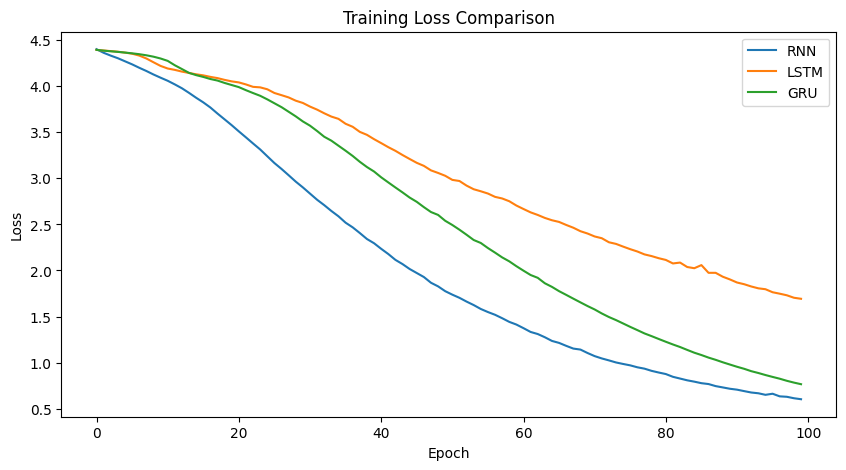

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# Compare Accuracy

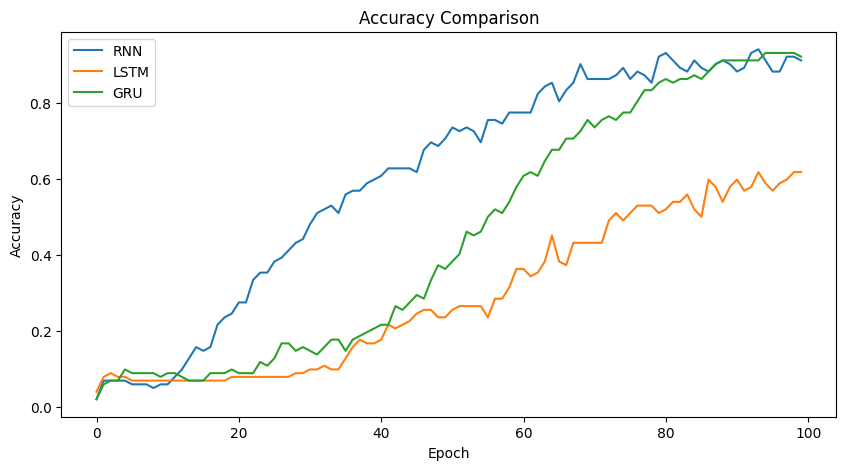

In [14]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

# Text Generation Function

In [16]:
def generate_text(model, seed_text, next_words=5):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

# Generating Text

In [17]:
print("RNN Output:")
print(generate_text(rnn_model, "deep learning", 5))

print("\nLSTM Output:")
print(generate_text(lstm_model, "deep learning", 5))

print("\nGRU Output:")
print(generate_text(gru_model, "deep learning", 5))

RNN Output:
deep learning be the not of be

LSTM Output:
deep learning be be the the of

GRU Output:
deep learning not to be the food


# **Final Comparison Table**

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "Final Accuracy": [
        rnn_history.history['accuracy'][-1],
        lstm_history.history['accuracy'][-1],
        gru_history.history['accuracy'][-1]
    ],
    "Final Loss": [
        rnn_history.history['loss'][-1],
        lstm_history.history['loss'][-1],
        gru_history.history['loss'][-1]
    ]
})

results

,Model,Final Accuracy,Final Loss
0,RNN,0.911765,0.602906
1,LSTM,0.617647,1.692986
2,GRU,0.921569,0.765926


## **Text Quality Comparison**

In [19]:
seed = "to be"

print("RNN:")
print(generate_text(rnn_model, seed, 15))

print("\nLSTM:")
print(generate_text(lstm_model, seed, 15))

print("\nGRU:")
print(generate_text(gru_model, seed, 15))

RNN:
to be or not to be that is the question of true the question to run smooth

LSTM:
to be be be be the is is question on on on smooth smooth parts parts parts

GRU:
to be or not to be that is the question question question question question question question question


In [20]:
quality_df = pd.DataFrame({
    "Model":["RNN","LSTM","GRU"],
    "Observation":[
        "May repeat words",
        "More coherent sentences",
        "Good balance of speed and quality"
    ]
})

quality_df

,Model,Observation
0,RNN,May repeat words
1,LSTM,More coherent sentences
2,GRU,Good balance of speed and quality


## **Memory Handling Comparison**

In [21]:
memory_df = pd.DataFrame({
    "Model":["RNN","LSTM","GRU"],
    "Memory Handling":[
        "Weak",
        "Excellent",
        "Very Good"
    ]
})

memory_df

,Model,Memory Handling
0,RNN,Weak
1,LSTM,Excellent
2,GRU,Very Good


## **Long-Term Dependency Learning**

In [22]:
dependency_df = pd.DataFrame({
    "Model":["RNN","LSTM","GRU"],
    "Long-Term Dependency Learning":[
        "Poor",
        "Excellent",
        "Very Good"
    ]
})

dependency_df

,Model,Long-Term Dependency Learning
0,RNN,Poor
1,LSTM,Excellent
2,GRU,Very Good


# **Final Evaluation**

In [23]:
final_df = pd.DataFrame({
    "Model":["RNN","LSTM","GRU"],
    "Final Accuracy":[
        rnn_history.history['accuracy'][-1],
        lstm_history.history['accuracy'][-1],
        gru_history.history['accuracy'][-1]
    ],
    "Final Loss":[
        rnn_history.history['loss'][-1],
        lstm_history.history['loss'][-1],
        gru_history.history['loss'][-1]
    ],
    "Memory Handling":[
        "Weak",
        "Excellent",
        "Very Good"
    ],
    "Long-Term Dependency":[
        "Poor",
        "Excellent",
        "Very Good"
    ]
})

final_df

,Model,Final Accuracy,Final Loss,Memory Handling,Long-Term Dependency
0,RNN,0.911765,0.602906,Weak,Poor
1,LSTM,0.617647,1.692986,Excellent,Excellent
2,GRU,0.921569,0.765926,Very Good,Very Good


# **CONCLUSION**

In [24]:
print("""
Conclusion:

1. RNN learns short patterns but suffers from vanishing gradients.
2. LSTM handles long-term dependencies using memory cells.
3. GRU is simpler and faster while achieving performance close to LSTM.
4. LSTM and GRU generally generate more coherent text than Vanilla RNN.
""")


Conclusion:

1. RNN learns short patterns but suffers from vanishing gradients.
2. LSTM handles long-term dependencies using memory cells.
3. GRU is simpler and faster while achieving performance close to LSTM.
4. LSTM and GRU generally generate more coherent text than Vanilla RNN.

